<a href="https://colab.research.google.com/github/n-daiki0612/umihotaru-yolo/blob/main/%E3%83%88%E3%83%A9%E3%83%83%E3%82%AD%E3%83%B3%E3%82%B0_YOLO_SAM2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. ライブラリとSAM2のセットアップ

In [ ]:
%cd /content

%pip install -q -U ultralytics psutil

!rm -rf /content/sam2
!rm -rf /content/sam2_repo

!git clone -q https://github.com/facebookresearch/sam2.git /content/sam2_repo

%cd /content/sam2_repo

# CUDA拡張なしでインストール
!SAM2_BUILD_CUDA=0 python -m pip install -q -e ".[notebooks]"

!mkdir -p /content/sam2_repo/checkpoints

!wget -q \
  -O /content/sam2_repo/checkpoints/sam2.1_hiera_small.pt \
  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

%cd /content

print("セットアップ完了")


/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.7 MB/s eta 0:00:00
/content/sam2_repo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━

## 2. SAM2 importとGPU確認

In [ ]:
from pathlib import Path
import sys
import importlib
import importlib.util
import torch
import ultralytics

SAM2_ROOT = Path("/content/sam2_repo")
SAM2_PACKAGE_DIR = SAM2_ROOT / "sam2"
SAM2_BUILD_FILE = SAM2_PACKAGE_DIR / "build_sam.py"
SAM2_INIT_FILE = SAM2_PACKAGE_DIR / "__init__.py"

print("torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU使用可能:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("ultralytics:", ultralytics.__version__)
print("build_sam.py:", SAM2_BUILD_FILE.is_file())
print("__init__.py:", SAM2_INIT_FILE.is_file())

if not SAM2_BUILD_FILE.is_file() or not SAM2_INIT_FILE.is_file():
    raise FileNotFoundError("SAM2のcloneが正常ではありません。")

# 過去に別のsam2をimportしていた場合のキャッシュを除去
for name in list(sys.modules):
    if name == "sam2" or name.startswith("sam2."):
        del sys.modules[name]

root = str(SAM2_ROOT)
sys.path = [p for p in sys.path if p != root]
sys.path.insert(0, root)
importlib.invalidate_caches()

spec = importlib.util.find_spec("sam2")
expected = SAM2_INIT_FILE.resolve()

print("sam2 origin:", spec.origin if spec else None)

if spec is None or spec.origin is None:
    raise RuntimeError("sam2を通常パッケージとして認識できていません。")

if Path(spec.origin).resolve() != expected:
    raise RuntimeError(
        f"別のsam2を読み込んでいます。 expected={expected}, actual={spec.origin}"
    )

from sam2.build_sam import build_sam2_video_predictor

print("SAM2 import OK")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch: 2.11.0+cu128
CUDA: 12.8
GPU使用可能: True
GPU: Tesla T4
ultralytics: 8.4.121
build_sam.py: True
__init__.py: True
sam2 origin: /content/sam2_repo/sam2/__init__.py
SAM2 import OK


## 3. 学習済みYOLOモデルをアップロード

In [ ]:
from google.colab import files
from pathlib import Path
import os

os.chdir("/content")

print("YOLOモデル（.pt）を1つ選択してください")
uploaded_model = files.upload()

model_candidates = [
    Path("/content") / filename
    for filename in uploaded_model
    if Path(filename).suffix.lower() == ".pt"
]

if len(model_candidates) != 1:
    raise RuntimeError(
        f".ptファイルを1つだけ選択してください: {model_candidates}"
    )

LOCAL_MODEL_PATH = model_candidates[0]

if not LOCAL_MODEL_PATH.is_file():
    raise FileNotFoundError(LOCAL_MODEL_PATH)

print("モデル:", LOCAL_MODEL_PATH)


## 4. 動画をアップロード

In [ ]:
from google.colab import files
from pathlib import Path
import os

os.chdir("/content")

print("動画を1つ選択してください")
uploaded_video = files.upload()

video_extensions = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

video_candidates = [
    Path("/content") / filename
    for filename in uploaded_video
    if Path(filename).suffix.lower() in video_extensions
]

if len(video_candidates) != 1:
    raise RuntimeError(
        f"動画ファイルを1つだけ選択してください: {video_candidates}"
    )

LOCAL_VIDEO_PATH = video_candidates[0]

if not LOCAL_VIDEO_PATH.is_file():
    raise FileNotFoundError(LOCAL_VIDEO_PATH)

print("動画:", LOCAL_VIDEO_PATH)


あらかじめアップロードしておいた際はこちら


In [ ]:
LOCAL_MODEL_PATH = "/content/best (3).pt"
LOCAL_VIDEO_PATH = "/content/umihotal2.mp4"

## 5. 設定

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/umihotaru_chunk_tracking/chunk100"
)

result_100 = {
    "output_dir": OUTPUT_DIR,
    "track_csv": OUTPUT_DIR / "tracks.csv",
    "motion_csv": OUTPUT_DIR / "motion_summary.csv",
    "correction_csv": OUTPUT_DIR / "yolo_corrections.csv",
    "progress_path": OUTPUT_DIR / "progress.json",
    "chunk_size": 100,
}

In [ ]:
from pathlib import Path

# =========================================================
# YOLO
# =========================================================

YOLO_IMGSZ = 960
YOLO_IOU = 0.70
YOLO_MAX_DET = 200

# YOLO推論自体はこの値以上を取得
YOLO_DETECT_CONF = 0.05

# 既存SAM2 IDのbboxをYOLOで上書きする最低confidence
YOLO_CORRECTION_CONF = 0.15

# 未一致YOLO検出を新規IDとして追加する最低confidence
YOLO_NEW_CONF = 0.05

# 1クラスモデルなら0。全クラスならNone
TARGET_CLASS_ID = 0


# =========================================================
# チャンク
# =========================================================

CHUNK_SIZE = 100

# 新規候補のみ、このフレーム数で動体判定
MOTION_CHECK_FRAMES = 20

# 初期位置からこのpixel以上離れたらmoving
MIN_MOVE_DISTANCE = 10.0

MIN_VALID_FRAMES = 5

# 判定不能IDを残すとRAM使用量が増えやすいのでFalse
KEEP_UNCERTAIN = False

# 同時追跡対象を増やしすぎない
MAX_ACTIVE_OBJECTS = 20


# 一度にSAM2へ入れるYOLO候補数
MOTION_BATCH_SIZE = 20

# YOLO候補を最大何件まで動体判定するか
# 30件程度なら50で十分
MAX_YOLO_CANDIDATES = 80

# 動体判定後、本追跡へ同時投入する最大数
MAX_ACTIVE_OBJECTS = 20


# =========================================================
# チャンク境界のYOLO対応付け
# =========================================================

MATCH_IOU_THRESHOLD = 0.05
MATCH_CENTER_DISTANCE = 80.0


# =========================================================
# マスク異常対策
# =========================================================

MIN_MASK_AREA = 2

# 画面面積の5%以上に膨張したマスクは異常候補として無視
MAX_MASK_AREA_RATIO = 0.05


# =========================================================
# RAM安全策
# =========================================================

# この値を下回ったら次チャンク開始前に停止
MIN_FREE_RAM_GB = 2.0


# =========================================================
# SAM2
# =========================================================

SAM2_ROOT = Path("/content/sam2_repo")
SAM2_CHECKPOINT = SAM2_ROOT / "checkpoints/sam2.1_hiera_small.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_s.yaml"


# =========================================================
# JPEG / 一時チャンク
# =========================================================

FRAME_DIR = Path("/content/umihotaru_frames")
CHUNK_ROOT = Path("/content/sam2_chunk_frames")


# =========================================================
# 出力
# =========================================================

OUTPUT_ROOT = Path("/content/umihotaru_chunk_tracking")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("設定完了")


設定完了


## 6. 動画をJPEGへ分割

OpenCVで**1フレームずつ読み込み、その場でJPEGへ保存**します。  
全フレーム画像をPythonリストに保持しないため、RAM負荷は小さいです。


In [ ]:
import shutil
import cv2

if FRAME_DIR.exists():
    shutil.rmtree(FRAME_DIR)

FRAME_DIR.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(LOCAL_VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"動画を開けません: {LOCAL_VIDEO_PATH}")

fps = float(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
metadata_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0 or width <= 0 or height <= 0:
    cap.release()
    raise RuntimeError(
        f"動画情報取得失敗: fps={fps}, size={width}x{height}"
    )

frame_index = 0

while True:
    ok, frame = cap.read()

    if not ok:
        break

    dst = FRAME_DIR / f"{frame_index:06d}.jpg"

    if not cv2.imwrite(
        str(dst),
        frame,
        [cv2.IMWRITE_JPEG_QUALITY, 95],
    ):
        cap.release()
        raise RuntimeError(f"JPEG保存失敗: {dst}")

    frame_index += 1

cap.release()

frame_paths = sorted(FRAME_DIR.glob("*.jpg"))

if not frame_paths:
    raise RuntimeError("JPEGフレームがありません。")

if frame_index != len(frame_paths):
    raise RuntimeError(
        f"読み込み数とJPEG数が不一致: {frame_index} vs {len(frame_paths)}"
    )

print("FPS:", fps)
print("解像度:", width, "x", height)
print("メタデータ上のフレーム数:", metadata_count)
print("実読み込み / JPEG数:", len(frame_paths))
print("JPEG保存先:", FRAME_DIR)


FPS: 30.00166861338228
解像度: 720 x 1280
メタデータ上のフレーム数: 899
実読み込み / JPEG数: 899
JPEG保存先: /content/umihotaru_frames


## 7. YOLOとSAM2を読み込み

RAM/GPU競合を減らすため、**YOLOはCPUに置いたまま**チャンク境界だけで使います。  
SAM2はGPUに置きます。


In [ ]:
import gc
import torch
from ultralytics import YOLO

if not torch.cuda.is_available():
    raise RuntimeError("GPUランタイムを使用してください。")

if not SAM2_CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"SAM2 checkpointがありません: {SAM2_CHECKPOINT}"
    )

# YOLOはCPU常駐
yolo_model = YOLO(str(LOCAL_MODEL_PATH))
yolo_model.to("cpu")

# SAM2はGPU
sam_predictor = build_sam2_video_predictor(
    SAM2_CONFIG,
    str(SAM2_CHECKPOINT),
    device="cuda",
)

major, _ = torch.cuda.get_device_capability(0)
AMP_DTYPE = torch.bfloat16 if major >= 8 else torch.float16

gc.collect()
torch.cuda.empty_cache()

print("YOLO device: CPU")
print("SAM2 GPU:", torch.cuda.get_device_name(0))
print("SAM2 autocast:", AMP_DTYPE)


YOLO device: CPU
SAM2 GPU: Tesla T4
SAM2 autocast: torch.float16


## 8. 省RAM用ヘルパー関数

In [ ]:
import csv
import gc
import math
import os
import shutil
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import psutil
import torch


def ram_status():
    vm = psutil.virtual_memory()

    return {
        "used_gb": (vm.total - vm.available) / 1024**3,
        "free_gb": vm.available / 1024**3,
        "total_gb": vm.total / 1024**3,
    }


def print_memory(prefix=""):
    ram = ram_status()

    text = (
        f"{prefix} RAM used={ram['used_gb']:.2f}GB "
        f"free={ram['free_gb']:.2f}GB "
        f"total={ram['total_gb']:.2f}GB"
    )

    if torch.cuda.is_available():
        gpu_alloc = torch.cuda.memory_allocated() / 1024**3
        gpu_reserved = torch.cuda.memory_reserved() / 1024**3

        text += (
            f" | GPU alloc={gpu_alloc:.2f}GB "
            f"reserved={gpu_reserved:.2f}GB"
        )

    print(text)


def cleanup_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()


def create_chunk_links(global_frame_paths, start, end, chunk_dir):
    """
    実体JPEGをコピーせず、チャンク分だけシンボリックリンクを作る。
    SAM2からは 000000.jpg, 000001.jpg ... と見える。
    """

    if chunk_dir.exists():
        shutil.rmtree(chunk_dir)

    chunk_dir.mkdir(parents=True, exist_ok=True)

    selected = global_frame_paths[start:end]

    for local_idx, src in enumerate(selected):
        dst = chunk_dir / f"{local_idx:06d}.jpg"

        os.symlink(
            str(src.resolve()),
            str(dst),
        )

    return len(selected)


def bbox_iou(a, b):
    ax1, ay1, ax2, ay2 = map(float, a)
    bx1, by1, bx2, by2 = map(float, b)

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)

    inter = iw * ih

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - inter

    return 0.0 if union <= 0 else inter / union


def bbox_center(box):
    x1, y1, x2, y2 = map(float, box)

    return (
        (x1 + x2) / 2.0,
        (y1 + y2) / 2.0,
    )


def center_distance(a, b):
    ax, ay = bbox_center(a)
    bx, by = bbox_center(b)

    return math.hypot(ax - bx, ay - by)


def mask_to_stats(mask_logits, frame_width, frame_height):
    """
    SAM2 mask logits -> center, bbox, area
    異常に大きなマスクはNone。
    """

    mask = (
        (mask_logits > 0.0)
        .squeeze()
        .detach()
        .cpu()
        .numpy()
    )

    ys, xs = np.where(mask)

    area = int(len(xs))

    if area < MIN_MASK_AREA:
        return None

    max_area = int(
        frame_width
        * frame_height
        * MAX_MASK_AREA_RATIO
    )

    if area > max_area:
        return None

    x1 = int(xs.min())
    y1 = int(ys.min())
    x2 = int(xs.max()) + 1
    y2 = int(ys.max()) + 1

    center_x = float(xs.mean())
    center_y = float(ys.mean())

    return {
        "center_x": center_x,
        "center_y": center_y,
        "box": np.array(
            [x1, y1, x2, y2],
            dtype=np.float32,
        ),
        "area": area,
    }


def run_yolo_on_frame(frame_path):
    """
    YOLOはCPUでチャンク先頭だけ実行。
    return: list[dict]
    """

    result = yolo_model.predict(
        source=str(frame_path),
        imgsz=YOLO_IMGSZ,
        conf=YOLO_DETECT_CONF,
        iou=YOLO_IOU,
        max_det=YOLO_MAX_DET,
        device="cpu",
        verbose=False,
    )[0]

    detections = []

    if result.boxes is None or len(result.boxes) == 0:
        del result
        gc.collect()
        return detections

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.int().cpu().numpy()

    order = np.argsort(confs)[::-1]

    for idx in order:
        class_id = int(classes[idx])

        if (
            TARGET_CLASS_ID is not None
            and class_id != TARGET_CLASS_ID
        ):
            continue

        detections.append(
            {
                "box": boxes[idx].astype(np.float32),
                "conf": float(confs[idx]),
                "class_id": class_id,
            }
        )

    del result
    gc.collect()

    return detections


def build_carry_and_new_candidates(
    carry_tracks,
    detections,
    next_id,
):
    """
    既存carry IDはYOLOと対応付けて補正。

    未一致YOLO検出については、
    まだ本追跡promptには入れず
    「動体判定候補」として全部返す。
    """

    carry_prompts = {}

    new_candidates = []

    correction_rows = []

    used_det = set()


    # =====================================================
    # 既存carry
    # =====================================================

    carry_ids = sorted(
        carry_tracks.keys()
    )


    if len(carry_ids) > MAX_ACTIVE_OBJECTS:

        print(
            f"警告: carry IDが"
            f"{len(carry_ids)}件あるため "
            f"{MAX_ACTIVE_OBJECTS}件へ制限"
        )

        carry_ids = carry_ids[
            :MAX_ACTIVE_OBJECTS
        ]


    for obj_id in carry_ids:

        carry = carry_tracks[
            obj_id
        ]

        carry_box = carry[
            "box"
        ]


        best_idx = None

        best_score = -1.0

        best_iou = 0.0

        best_dist = float(
            "inf"
        )


        # =================================================
        # YOLOとの対応付け
        # =================================================

        for det_idx, det in enumerate(
            detections
        ):

            if det_idx in used_det:
                continue


            iou = bbox_iou(
                carry_box,
                det["box"]
            )


            dist = center_distance(
                carry_box,
                det["box"]
            )


            if (
                iou
                < MATCH_IOU_THRESHOLD
                and
                dist
                > MATCH_CENTER_DISTANCE
            ):

                continue


            distance_score = max(
                0.0,
                1.0
                - dist
                / MATCH_CENTER_DISTANCE
            )


            score = (
                iou
                + 0.25
                * distance_score
            )


            if score > best_score:

                best_idx = det_idx

                best_score = score

                best_iou = iou

                best_dist = dist


        # =================================================
        # 空間的に対応した検出は
        # confidenceに関係なく「使用済み」にする
        #
        # これをしないと既存IDと同じ物体が
        # 新規候補として二重登録される可能性がある
        # =================================================

        if best_idx is not None:

            used_det.add(
                best_idx
            )


        # =================================================
        # confidenceが十分ならYOLO補正
        # =================================================

        if (
            best_idx is not None
            and
            detections[
                best_idx
            ]["conf"]
            >= YOLO_CORRECTION_CONF
        ):

            det = detections[
                best_idx
            ]

            prompt_box = det[
                "box"
            ]

            source = (
                "yolo_corrected"
            )

            prompt_conf = det[
                "conf"
            ]

            class_id = det[
                "class_id"
            ]


        else:

            # SAM2の前チャンクBBoxを
            # そのまま次へ
            prompt_box = (
                carry_box
            )

            source = (
                "sam2_carry"
            )

            prompt_conf = None

            class_id = carry[
                "class_id"
            ]


        carry_prompts[
            obj_id
        ] = {

            "box":
                np.asarray(
                    prompt_box,
                    dtype=np.float32
                ),

            "class_id":
                int(
                    class_id
                ),

            "source":
                source,

            "conf":
                prompt_conf,

            # carryなのでnewではない
            "is_new":
                False,
        }


        correction_rows.append(
            {
                "obj_id":
                    obj_id,

                "action":
                    source,

                "yolo_conf":
                    (
                        ""
                        if prompt_conf
                        is None
                        else prompt_conf
                    ),

                "match_iou":
                    (
                        ""
                        if best_idx
                        is None
                        else best_iou
                    ),

                "match_distance":
                    (
                        ""
                        if best_idx
                        is None
                        else best_dist
                    ),
            }
        )


    # =====================================================
    # 未一致YOLO
    #
    # ここでは10件でbreakしない
    # 全候補を動体判定へ回す
    # =====================================================

    for det_idx, det in enumerate(
        detections
    ):

        if det_idx in used_det:
            continue


        if (
            det["conf"]
            < YOLO_NEW_CONF
        ):
            continue


        if (
            len(
                new_candidates
            )
            >= MAX_YOLO_CANDIDATES
        ):
            break


        obj_id = next_id

        next_id += 1


        new_candidates.append(
            {
                "obj_id":
                    obj_id,

                "box":
                    np.asarray(
                        det["box"],
                        dtype=np.float32
                    ),

                "class_id":
                    int(
                        det["class_id"]
                    ),

                "conf":
                    float(
                        det["conf"]
                    ),
            }
        )


    print(
        "carry候補:",
        len(
            carry_prompts
        )
    )

    print(
        "SAM2動体判定へ回す新規候補:",
        len(
            new_candidates
        )
    )


    return (
        carry_prompts,
        new_candidates,
        correction_rows,
        next_id,
    )

def moving_judgement(history):
    """
    history: [(local_frame, x, y), ...]
    """

    if len(history) < MIN_VALID_FRAMES:
        return {
            "keep": KEEP_UNCERTAIN,
            "status": (
                "uncertain_keep"
                if KEEP_UNCERTAIN
                else "uncertain_remove"
            ),
            "max_move": None,
            "valid_frames": len(history),
        }

    first = history[: min(3, len(history))]

    start_x = float(
        np.median([p[1] for p in first])
    )

    start_y = float(
        np.median([p[2] for p in first])
    )

    max_move = 0.0

    for _, x, y in history:
        max_move = max(
            max_move,
            math.hypot(
                x - start_x,
                y - start_y
            )
        )

    keep = max_move >= MIN_MOVE_DISTANCE

    return {
        "keep": keep,
        "status": "moving" if keep else "static",
        "max_move": max_move,
        "valid_frames": len(history),
    }


print_memory("ヘルパー準備完了")


ヘルパー準備完了 RAM used=2.85GB free=9.82GB total=12.67GB | GPU alloc=0.34GB reserved=0.45GB


YOLO確認フレーム: /content/umihotaru_frames/000000.jpg
YOLO検出数: 91

========== 検出内容 ==========
  1 | conf=0.4104 | class=0 | box=[      384.2       441.9       394.2         452]
  2 | conf=0.3719 | class=0 | box=[        362       931.3       373.9       940.3]
  3 | conf=0.3704 | class=0 | box=[      166.2       881.5       176.8       894.3]
  4 | conf=0.2919 | class=0 | box=[      542.2       463.6       550.9         473]
  5 | conf=0.2801 | class=0 | box=[      134.2         917       144.4       927.8]
  6 | conf=0.2293 | class=0 | box=[      164.7       606.3       179.7       617.8]
  7 | conf=0.2201 | class=0 | box=[      381.7       946.6       391.8       954.9]
  8 | conf=0.2192 | class=0 | box=[      258.8       908.8       275.3       926.9]
  9 | conf=0.2167 | class=0 | box=[      562.2         867         573       876.6]
 10 | conf=0.2122 | class=0 | box=[      562.5       701.4       571.5       713.7]
 11 | conf=0.2109 | class=0 | box=[      409.2       740.6       424.4 

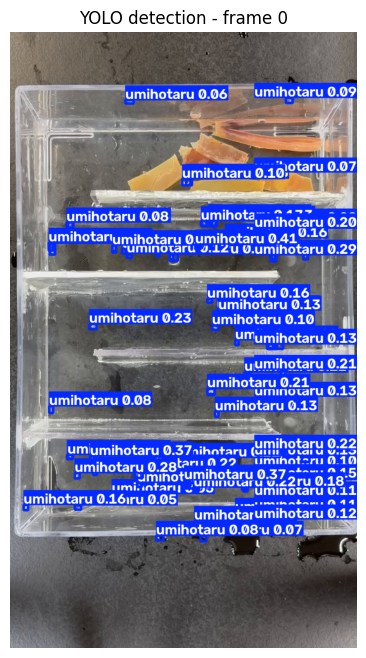


YOLO確認用メモリ解放完了


In [ ]:
# =========================================================
# 1フレーム目のYOLO検出結果を可視化
# =========================================================

import gc
import matplotlib.pyplot as plt


# 1フレーム目
VIS_FRAME_IDX = 0

vis_frame_path = frame_paths[
    VIS_FRAME_IDX
]

print(
    "YOLO確認フレーム:",
    vis_frame_path
)


# =========================================================
# YOLO推論
# =========================================================

vis_result = yolo_model.predict(
    source=str(
        vis_frame_path
    ),

    imgsz=YOLO_IMGSZ,

    conf=YOLO_DETECT_CONF,

    iou=YOLO_IOU,

    max_det=YOLO_MAX_DET,

    # 現在の省RAM版ではYOLOをCPUに置いている
    device="cpu",

    verbose=False,
)[0]


# =========================================================
# 検出数表示
# =========================================================

if (
    vis_result.boxes is None
    or len(vis_result.boxes) == 0
):

    print(
        "YOLO検出数: 0"
    )

else:

    print(
        "YOLO検出数:",
        len(
            vis_result.boxes
        )
    )


    print()
    print(
        "========== 検出内容 =========="
    )


    for i, box in enumerate(
        vis_result.boxes
    ):

        confidence = float(
            box.conf[0]
            .cpu()
            .item()
        )

        class_id = int(
            box.cls[0]
            .cpu()
            .item()
        )

        xyxy = (
            box.xyxy[0]
            .cpu()
            .numpy()
        )


        print(
            f"{i + 1:3d} | "
            f"conf={confidence:.4f} | "
            f"class={class_id} | "
            f"box={xyxy.round(1)}"
        )


# =========================================================
# Bounding Box付き画像を作成
# =========================================================

annotated = (
    vis_result.plot()
)


# =========================================================
# 表示
# =========================================================

plt.figure(
    figsize=(14, 8)
)

# UltralyticsはBGRなのでRGBへ
plt.imshow(
    annotated[
        ...,
        ::-1
    ]
)

plt.axis(
    "off"
)

plt.title(
    f"YOLO detection - frame {VIS_FRAME_IDX}"
)

plt.show()


# =========================================================
# 確認用データを解放
# =========================================================

plt.close(
    "all"
)

del annotated
del vis_result

gc.collect()


print()
print(
    "YOLO確認用メモリ解放完了"
)

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Google Driveへ直接保存
OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/umihotaru_chunk_tracking"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("CSV保存先:", OUTPUT_ROOT)

## 9. チャンク追跡本体

重要なのは、`sam_predictor.init_state()` に **動画全体のJPEGフォルダを渡さない**ことです。  
毎回チャンク用の100枚だけをシンボリックリンクした一時フォルダを渡します。


In [ ]:
# =========================================================
# Google Drive逐次保存 + 途中再開
# =========================================================

from google.colab import drive
from pathlib import Path

import csv
import json
import os
import numpy as np


# Google Drive
drive.mount(
    "/content/drive"
)


# =========================================================
# 出力先をGoogle Driveへ変更
# =========================================================

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/umihotaru_chunk_tracking"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "保存先:",
    OUTPUT_ROOT
)


# =========================================================
# progress.json 保存
# =========================================================

def save_tracking_progress(
    progress_path,
    next_chunk_start,
    next_id,
    carry_tracks,
    chunk_size,
):
    """
    最後に正常終了したチャンクの状態を保存。

    next_chunk_start:
        次回開始するフレーム番号
    """

    serializable_carry = {}

    for obj_id, data in carry_tracks.items():

        serializable_carry[
            str(obj_id)
        ] = {
            "box":
                np.asarray(
                    data["box"]
                ).tolist(),

            "class_id":
                int(
                    data["class_id"]
                ),

            "last_frame":
                int(
                    data["last_frame"]
                ),
        }


    progress = {
        "next_chunk_start":
            int(
                next_chunk_start
            ),

        "next_id":
            int(
                next_id
            ),

        "chunk_size":
            int(
                chunk_size
            ),

        "carry_tracks":
            serializable_carry,
    }


    # 一旦tmpへ保存してから置換
    # progress.jsonの途中破損を防ぐ
    temp_path = Path(
        str(progress_path)
        + ".tmp"
    )


    with temp_path.open(
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            progress,
            f,
            ensure_ascii=False,
            indent=2,
        )

        f.flush()

        os.fsync(
            f.fileno()
        )


    os.replace(
        temp_path,
        progress_path
    )


# =========================================================
# progress.json 読み込み
# =========================================================

def load_tracking_progress(
    progress_path,
):

    if not progress_path.exists():

        return None


    with progress_path.open(
        "r",
        encoding="utf-8"
    ) as f:

        progress = json.load(
            f
        )


    carry_tracks = {}

    for obj_id, data in (
        progress.get(
            "carry_tracks",
            {}
        ).items()
    ):

        carry_tracks[
            int(obj_id)
        ] = {
            "box":
                np.asarray(
                    data["box"],
                    dtype=np.float32
                ),

            "class_id":
                int(
                    data["class_id"]
                ),

            "last_frame":
                int(
                    data["last_frame"]
                ),
        }


    progress[
        "carry_tracks"
    ] = carry_tracks


    return progress


# =========================================================
# CSV flush
# =========================================================

def flush_csv_files(
    *files,
):

    for f in files:

        f.flush()

        try:
            os.fsync(
                f.fileno()
            )

        except OSError:
            pass


# =========================================================
# 未完了チャンクのCSV行を削除
#
# 例:
# progress = 300
#
# tracks.csv
#   frame < 300 のみ残す
#
# motion/correction
#   chunk_start < 300 のみ残す
#
# Colabが250フレーム付近で落ち、
# CSVだけ途中まで書かれていても重複しない
# =========================================================

def trim_csv_for_resume(
    csv_path,
    resume_frame,
    column_name,
):

    csv_path = Path(
        csv_path
    )


    if not csv_path.exists():

        return


    temp_path = Path(
        str(csv_path)
        + ".resume_tmp"
    )


    with (
        csv_path.open(
            "r",
            newline="",
            encoding="utf-8"
        ) as src,

        temp_path.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as dst,
    ):

        reader = csv.DictReader(
            src
        )


        if reader.fieldnames is None:

            return


        writer = csv.DictWriter(
            dst,
            fieldnames=
                reader.fieldnames
        )

        writer.writeheader()


        for row in reader:

            try:

                value = int(
                    float(
                        row[
                            column_name
                        ]
                    )
                )

            except (
                KeyError,
                ValueError,
                TypeError,
            ):

                continue


            if value < resume_frame:

                writer.writerow(
                    row
                )


        dst.flush()

        try:

            os.fsync(
                dst.fileno()
            )

        except OSError:

            pass


    os.replace(
        temp_path,
        csv_path
    )


print(
    "途中再開機能準備完了"
)

In [ ]:
def run_chunked_tracking(
    chunk_size=100,
    output_prefix="chunk100",
    resume=True,
):
    """
    YOLO + SAM2 チャンク追跡。

    ・新規YOLO候補は10個ずつSAM2で動体判定
    ・CSVはGoogle Driveへ直接保存
    ・チャンク完了ごとにflush
    ・progress.jsonへ
        next_chunk_start
        next_id
        carry_tracks
      を保存
    ・Colab再起動後も続きから再開可能
    """

    if chunk_size < 2:

        raise ValueError(
            "chunk_sizeは2以上にしてください。"
        )


    # =====================================================
    # 出力先
    # =====================================================

    output_dir = (
        OUTPUT_ROOT
        / output_prefix
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    track_csv = (
        output_dir
        / "tracks.csv"
    )

    motion_csv = (
        output_dir
        / "motion_summary.csv"
    )

    correction_csv = (
        output_dir
        / "yolo_corrections.csv"
    )

    progress_path = (
        output_dir
        / "progress.json"
    )


    total_frames = len(
        frame_paths
    )


    # =====================================================
    # 初期状態
    # =====================================================

    start_frame = 0

    carry_tracks = {}

    next_id = 1


    # =====================================================
    # 途中再開
    # =====================================================

    progress = None


    if (
        resume
        and progress_path.exists()
    ):

        progress = (
            load_tracking_progress(
                progress_path
            )
        )


    if progress is not None:

        saved_chunk_size = int(
            progress.get(
                "chunk_size",
                chunk_size
            )
        )


        if (
            saved_chunk_size
            != chunk_size
        ):

            raise ValueError(
                "以前の実験とchunk_sizeが異なります。\n"
                f"保存済み: {saved_chunk_size}\n"
                f"今回: {chunk_size}\n"
                "比較実験ではoutput_prefixを変更してください。"
            )


        start_frame = int(
            progress[
                "next_chunk_start"
            ]
        )


        next_id = int(
            progress[
                "next_id"
            ]
        )


        carry_tracks = (
            progress[
                "carry_tracks"
            ]
        )


        print()
        print(
            "========== 途中再開 =========="
        )

        print(
            "再開フレーム:",
            start_frame
        )

        print(
            "next_id:",
            next_id
        )

        print(
            "carry:",
            len(
                carry_tracks
            )
        )


        # =============================================
        # 最後の未完了チャンクの途中データを削除
        # =============================================

        trim_csv_for_resume(
            track_csv,
            start_frame,
            "frame",
        )

        trim_csv_for_resume(
            motion_csv,
            start_frame,
            "chunk_start",
        )

        trim_csv_for_resume(
            correction_csv,
            start_frame,
            "chunk_start",
        )


    else:

        print()
        print(
            "========== 新規実験 =========="
        )

        print(
            "frame 0から開始"
        )


    # =====================================================
    # すでに全部終了している
    # =====================================================

    if (
        start_frame
        >= total_frames
    ):

        print(
            "この実験はすでに完了しています。"
        )

        return {
            "output_dir":
                output_dir,

            "track_csv":
                track_csv,

            "motion_csv":
                motion_csv,

            "correction_csv":
                correction_csv,

            "progress_path":
                progress_path,

            "chunk_size":
                chunk_size,
        }


    # =====================================================
    # CSV mode
    # =====================================================

    # 再開時はappend
    append_mode = (
        start_frame > 0
        and track_csv.exists()
    )


    mode = (
        "a"
        if append_mode
        else "w"
    )


    # =====================================================
    # CSVを開く
    # =====================================================

    with (
        track_csv.open(
            mode,
            newline="",
            encoding="utf-8",
        ) as track_file,

        motion_csv.open(
            mode,
            newline="",
            encoding="utf-8",
        ) as motion_file,

        correction_csv.open(
            mode,
            newline="",
            encoding="utf-8",
        ) as correction_file,
    ):

        track_writer = csv.writer(
            track_file
        )

        motion_writer = csv.writer(
            motion_file
        )

        correction_writer = csv.writer(
            correction_file
        )


        # =================================================
        # 新規CSVのみheader
        # =================================================

        if not append_mode:

            track_writer.writerow(
                [
                    "frame",
                    "obj_id",
                    "center_x",
                    "center_y",
                    "x1",
                    "y1",
                    "x2",
                    "y2",
                    "mask_area",
                    "chunk_start",
                    "prompt_source",
                    "class_id",
                ]
            )


            motion_writer.writerow(
                [
                    "chunk_start",
                    "obj_id",
                    "valid_frames",
                    "max_move_px",
                    "status",
                ]
            )


            correction_writer.writerow(
                [
                    "chunk_start",
                    "obj_id",
                    "action",
                    "yolo_conf",
                    "match_iou",
                    "match_distance",
                ]
            )


            flush_csv_files(
                track_file,
                motion_file,
                correction_file,
            )


        # =================================================
        # チャンク
        # =================================================

        for chunk_start in range(
            start_frame,
            total_frames,
            chunk_size,
        ):

            chunk_end = min(
                chunk_start
                + chunk_size,

                total_frames,
            )


            chunk_len = (
                chunk_end
                - chunk_start
            )


            print()
            print(
                "=" * 70
            )

            print(
                f"CHUNK "
                f"{chunk_start} - "
                f"{chunk_end - 1} "
                f"({chunk_len} frames)"
            )


            print_memory(
                "チャンク開始前"
            )


            # =================================================
            # RAM
            # =================================================

            ram = ram_status()


            if (
                ram[
                    "free_gb"
                ]
                < MIN_FREE_RAM_GB
            ):

                raise MemoryError(
                    f"空きRAMが"
                    f"{ram['free_gb']:.2f}GBしかありません。"
                )


            # =================================================
            # chunk directory
            # =================================================

            chunk_dir = (
                CHUNK_ROOT
                / (
                    f"{output_prefix}_"
                    f"{chunk_start:06d}"
                )
            )


            state = None


            try:

                # =================================================
                # チャンク画像
                # =================================================

                created = (
                    create_chunk_links(
                        frame_paths,
                        chunk_start,
                        chunk_end,
                        chunk_dir,
                    )
                )


                if (
                    created
                    != chunk_len
                ):

                    raise RuntimeError(
                        "チャンクJPEG作成数が一致しません。"
                    )


                # =================================================
                # YOLO
                # =================================================

                detections = (
                    run_yolo_on_frame(
                        frame_paths[
                            chunk_start
                        ]
                    )
                )


                print(
                    "YOLO検出候補数:",
                    len(
                        detections
                    )
                )


                # =================================================
                # carry / new分離
                # =================================================

                (
                    carry_prompts,
                    new_candidates,
                    correction_rows,
                    next_id,
                ) = (
                    build_carry_and_new_candidates(
                        carry_tracks,
                        detections,
                        next_id,
                    )
                )


                # =================================================
                # carry補正ログ
                # =================================================

                for row in (
                    correction_rows
                ):

                    correction_writer.writerow(
                        [
                            chunk_start,
                            row["obj_id"],
                            row["action"],
                            row["yolo_conf"],
                            row["match_iou"],
                            row["match_distance"],
                        ]
                    )


                # =================================================
                # 新規候補を10個ずつSAM2動体判定
                # =================================================

                (
                    moving_new_prompts,
                    candidate_results,
                ) = (
                    filter_new_candidates_in_batches(
                        new_candidates=
                            new_candidates,

                        chunk_start=
                            chunk_start,

                        chunk_end=
                            chunk_end,

                        output_prefix=
                            output_prefix,

                        motion_writer=
                            motion_writer,
                    )
                )


                # =================================================
                # 新規候補ログ
                # =================================================

                candidate_by_id = {
                    int(
                        candidate[
                            "obj_id"
                        ]
                    ):
                    candidate

                    for candidate
                    in new_candidates
                }


                for result in (
                    candidate_results
                ):

                    obj_id = int(
                        result[
                            "obj_id"
                        ]
                    )


                    candidate = (
                        candidate_by_id[
                            obj_id
                        ]
                    )


                    if result[
                        "keep"
                    ]:

                        action = (
                            "yolo_new_moving"
                        )

                    else:

                        action = (
                            "yolo_new_"
                            + result[
                                "status"
                            ]
                        )


                    correction_writer.writerow(
                        [
                            chunk_start,
                            obj_id,
                            action,
                            candidate[
                                "conf"
                            ],
                            "",
                            "",
                        ]
                    )


                # =================================================
                # 本追跡prompt
                # =================================================

                prompts = dict(
                    carry_prompts
                )


                remaining_slots = max(
                    0,
                    MAX_ACTIVE_OBJECTS
                    - len(
                        prompts
                    ),
                )


                moving_items = sorted(
                    moving_new_prompts.items(),

                    key=lambda item: (
                        item[1][
                            "conf"
                        ]

                        if item[1][
                            "conf"
                        ]
                        is not None

                        else -1.0
                    ),

                    reverse=True,
                )


                for (
                    obj_id,
                    prompt,
                ) in moving_items[
                    :remaining_slots
                ]:

                    prompts[
                        obj_id
                    ] = prompt


                print()
                print(
                    "========== 本追跡候補 =========="
                )

                print(
                    "carry:",
                    len(
                        carry_prompts
                    )
                )

                print(
                    "YOLO新規候補:",
                    len(
                        new_candidates
                    )
                )

                print(
                    "動体判定通過:",
                    len(
                        moving_new_prompts
                    )
                )

                print(
                    "本追跡SAM2へ投入:",
                    len(
                        prompts
                    )
                )


                # =================================================
                # YOLO関連解放
                # =================================================

                del detections
                del new_candidates
                del candidate_results
                del candidate_by_id
                del moving_new_prompts
                del moving_items

                gc.collect()


                # =================================================
                # 本追跡対象なし
                #
                # これも正常終了したチャンクとして保存
                # =================================================

                if (
                    len(
                        prompts
                    )
                    == 0
                ):

                    carry_tracks = {}


                    flush_csv_files(
                        track_file,
                        motion_file,
                        correction_file,
                    )


                    save_tracking_progress(
                        progress_path=
                            progress_path,

                        next_chunk_start=
                            chunk_end,

                        next_id=
                            next_id,

                        carry_tracks=
                            carry_tracks,

                        chunk_size=
                            chunk_size,
                    )


                    print(
                        f"Drive保存完了: "
                        f"次回 frame {chunk_end} から"
                    )


                    continue


                # =================================================
                # 本追跡SAM2 state
                # =================================================

                state = (
                    sam_predictor.init_state(
                        video_path=str(
                            chunk_dir
                        ),

                        offload_video_to_cpu=True,

                        offload_state_to_cpu=False,

                        async_loading_frames=False,
                    )
                )


                # =================================================
                # prompt
                # =================================================

                with (
                    torch.inference_mode(),

                    torch.autocast(
                        "cuda",
                        dtype=AMP_DTYPE,
                    ),
                ):

                    for (
                        obj_id,
                        prompt,
                    ) in prompts.items():

                        sam_predictor.add_new_points_or_box(
                            inference_state=
                                state,

                            frame_idx=
                                0,

                            obj_id=
                                int(
                                    obj_id
                                ),

                            box=
                                np.asarray(
                                    prompt[
                                        "box"
                                    ],
                                    dtype=
                                        np.float32,
                                ),
                        )


                print_memory(
                    "本追跡SAM2 state作成後"
                )


                # =================================================
                # 最初のprobe区間
                # =================================================

                new_ids = {
                    obj_id

                    for (
                        obj_id,
                        prompt
                    )
                    in prompts.items()

                    if prompt[
                        "is_new"
                    ]
                }


                probe_history = (
                    defaultdict(
                        list
                    )
                )


                probe_rows = []

                last_stats = {}


                probe_frames = min(
                    MOTION_CHECK_FRAMES,
                    chunk_len,
                )


                probe_max_track = (
                    probe_frames
                    - 1
                )


                with (
                    torch.inference_mode(),

                    torch.autocast(
                        "cuda",
                        dtype=AMP_DTYPE,
                    ),
                ):

                    for (
                        local_frame,
                        obj_ids,
                        mask_logits,
                    ) in (
                        sam_predictor
                        .propagate_in_video(
                            state,

                            start_frame_idx=
                                0,

                            max_frame_num_to_track=
                                probe_max_track,

                            reverse=
                                False,
                        )
                    ):

                        local_frame = int(
                            local_frame
                        )


                        global_frame = (
                            chunk_start
                            + local_frame
                        )


                        for (
                            i,
                            obj_id,
                        ) in enumerate(
                            obj_ids
                        ):

                            obj_id = int(
                                obj_id
                            )


                            stats = (
                                mask_to_stats(
                                    mask_logits[
                                        i
                                    ],
                                    width,
                                    height,
                                )
                            )


                            if (
                                stats
                                is None
                            ):

                                continue


                            last_stats[
                                obj_id
                            ] = {
                                "global_frame":
                                    global_frame,
                                **stats,
                            }


                            if (
                                obj_id
                                in new_ids
                            ):

                                probe_history[
                                    obj_id
                                ].append(
                                    (
                                        local_frame,

                                        stats[
                                            "center_x"
                                        ],

                                        stats[
                                            "center_y"
                                        ],
                                    )
                                )


                            probe_rows.append(
                                {
                                    "frame":
                                        global_frame,

                                    "obj_id":
                                        obj_id,

                                    "stats":
                                        stats,
                                }
                            )


                # =================================================
                # 無効ID
                # =================================================

                rejected_ids = set()


                for obj_id in (
                    new_ids
                ):

                    judgement = (
                        moving_judgement(
                            probe_history.get(
                                obj_id,
                                [],
                            )
                        )
                    )


                    motion_writer.writerow(
                        [
                            chunk_start,

                            obj_id,

                            judgement[
                                "valid_frames"
                            ],

                            (
                                ""

                                if judgement[
                                    "max_move"
                                ]
                                is None

                                else judgement[
                                    "max_move"
                                ]
                            ),

                            judgement[
                                "status"
                            ],
                        ]
                    )


                    if not judgement[
                        "keep"
                    ]:

                        rejected_ids.add(
                            obj_id
                        )


                # carry含め、
                # 最初の区間でmaskが無いID
                carry_prompt_ids = {
                    obj_id

                    for (
                        obj_id,
                        prompt
                    )
                    in prompts.items()

                    if not prompt[
                        "is_new"
                    ]
                }


                for obj_id in (
                    carry_prompt_ids
                ):

                    if (
                        obj_id
                        not in last_stats
                    ):

                        rejected_ids.add(
                            obj_id
                        )


                # =================================================
                # rejected除去
                # =================================================

                if rejected_ids:

                    with (
                        torch.inference_mode(),

                        torch.autocast(
                            "cuda",
                            dtype=AMP_DTYPE,
                        ),
                    ):

                        for obj_id in sorted(
                            rejected_ids
                        ):

                            sam_predictor.remove_object(
                                state,
                                obj_id,
                                strict=False,
                                need_output=False,
                            )


                active_ids = (
                    set(
                        prompts.keys()
                    )
                    - rejected_ids
                )


                print(
                    "本追跡無効除外:",
                    len(
                        rejected_ids
                    ),
                    "| active:",
                    len(
                        active_ids
                    )
                )


                # =================================================
                # probe CSV
                # =================================================

                for row in (
                    probe_rows
                ):

                    obj_id = row[
                        "obj_id"
                    ]


                    if (
                        obj_id
                        not in active_ids
                    ):

                        continue


                    stats = row[
                        "stats"
                    ]

                    box = stats[
                        "box"
                    ]

                    prompt = prompts[
                        obj_id
                    ]


                    track_writer.writerow(
                        [
                            row[
                                "frame"
                            ],

                            obj_id,

                            stats[
                                "center_x"
                            ],

                            stats[
                                "center_y"
                            ],

                            float(
                                box[0]
                            ),

                            float(
                                box[1]
                            ),

                            float(
                                box[2]
                            ),

                            float(
                                box[3]
                            ),

                            stats[
                                "area"
                            ],

                            chunk_start,

                            prompt[
                                "source"
                            ],

                            prompt[
                                "class_id"
                            ],
                        ]
                    )


                del probe_rows
                del probe_history

                gc.collect()


                # =================================================
                # 残りのチャンク
                # =================================================

                next_local_frame = (
                    probe_frames
                )


                if (
                    active_ids

                    and
                    next_local_frame
                    < chunk_len
                ):

                    with (
                        torch.inference_mode(),

                        torch.autocast(
                            "cuda",
                            dtype=AMP_DTYPE,
                        ),
                    ):

                        for (
                            local_frame,
                            obj_ids,
                            mask_logits,
                        ) in (
                            sam_predictor
                            .propagate_in_video(
                                state,

                                start_frame_idx=
                                    next_local_frame,

                                reverse=
                                    False,
                            )
                        ):

                            local_frame = int(
                                local_frame
                            )


                            if (
                                local_frame
                                >= chunk_len
                            ):

                                break


                            global_frame = (
                                chunk_start
                                + local_frame
                            )


                            for (
                                i,
                                obj_id,
                            ) in enumerate(
                                obj_ids
                            ):

                                obj_id = int(
                                    obj_id
                                )


                                if (
                                    obj_id
                                    not in active_ids
                                ):

                                    continue


                                stats = (
                                    mask_to_stats(
                                        mask_logits[
                                            i
                                        ],
                                        width,
                                        height,
                                    )
                                )


                                if (
                                    stats
                                    is None
                                ):

                                    continue


                                last_stats[
                                    obj_id
                                ] = {
                                    "global_frame":
                                        global_frame,

                                    **stats,
                                }


                                box = stats[
                                    "box"
                                ]

                                prompt = prompts[
                                    obj_id
                                ]


                                track_writer.writerow(
                                    [
                                        global_frame,

                                        obj_id,

                                        stats[
                                            "center_x"
                                        ],

                                        stats[
                                            "center_y"
                                        ],

                                        float(
                                            box[0]
                                        ),

                                        float(
                                            box[1]
                                        ),

                                        float(
                                            box[2]
                                        ),

                                        float(
                                            box[3]
                                        ),

                                        stats[
                                            "area"
                                        ],

                                        chunk_start,

                                        prompt[
                                            "source"
                                        ],

                                        prompt[
                                            "class_id"
                                        ],
                                    ]
                                )


                # =================================================
                # carry作成
                # =================================================

                new_carry_tracks = {}


                minimum_carry_frame = max(
                    chunk_start,
                    chunk_end - 5,
                )


                for obj_id in (
                    active_ids
                ):

                    stats = (
                        last_stats.get(
                            obj_id
                        )
                    )


                    if (
                        stats
                        is None
                    ):

                        continue


                    if (
                        stats[
                            "global_frame"
                        ]
                        < minimum_carry_frame
                    ):

                        continue


                    new_carry_tracks[
                        obj_id
                    ] = {
                        "box":
                            stats[
                                "box"
                            ].copy(),

                        "class_id":
                            prompts[
                                obj_id
                            ][
                                "class_id"
                            ],

                        "last_frame":
                            stats[
                                "global_frame"
                            ],
                    }


                carry_tracks = (
                    new_carry_tracks
                )


                print(
                    "次チャンクcarry:",
                    len(
                        carry_tracks
                    )
                )


                # =================================================
                # ★ このチャンクのCSVをDriveへ確定
                # =================================================

                flush_csv_files(
                    track_file,
                    motion_file,
                    correction_file,
                )


                # =================================================
                # ★ 次回再開位置 + ID状態保存
                # =================================================

                save_tracking_progress(
                    progress_path=
                        progress_path,

                    next_chunk_start=
                        chunk_end,

                    next_id=
                        next_id,

                    carry_tracks=
                        carry_tracks,

                    chunk_size=
                        chunk_size,
                )


                print(
                    "Drive保存完了:",
                    f"frame 0 - {chunk_end - 1}"
                )

                print(
                    "次回再開位置:",
                    chunk_end
                )


            # =====================================================
            # RAM解放
            # =====================================================

            finally:

                if (
                    state
                    is not None
                ):

                    try:

                        sam_predictor.reset_state(
                            state
                        )

                    except Exception:

                        pass


                    del state


                if chunk_dir.exists():

                    shutil.rmtree(
                        chunk_dir,
                        ignore_errors=True
                    )


                cleanup_memory()


                print_memory(
                    "チャンク解放後"
                )


    # =========================================================
    # 終了
    # =========================================================

    print()
    print(
        "===================================="
    )

    print(
        "追跡完了"
    )

    print(
        "tracks:",
        track_csv
    )

    print(
        "motion:",
        motion_csv
    )

    print(
        "corrections:",
        correction_csv
    )

    print(
        "progress:",
        progress_path
    )


    return {
        "output_dir":
            output_dir,

        "track_csv":
            track_csv,

        "motion_csv":
            motion_csv,

        "correction_csv":
            correction_csv,

        "progress_path":
            progress_path,

        "chunk_size":
            chunk_size,
    }

## 10. 100フレームごとに実行

In [ ]:
cleanup_memory()
print_memory("100-frame実験開始")

result_100 = run_chunked_tracking(
    chunk_size=100,
    output_prefix="chunk100",
)


100-frame実験開始 RAM used=2.87GB free=9.80GB total=12.67GB | GPU alloc=0.34GB reserved=0.35GB

CHUNK 0 - 99 (100 frames)
チャンク開始前 RAM used=2.87GB free=9.80GB total=12.67GB | GPU alloc=0.34GB reserved=0.35GB
YOLO検出候補数: 91
carry候補: 0
SAM2動体判定へ回す新規候補: 80
carry候補: 0
動体判定へ回す新規候補: 80

========== YOLO候補動体判定 ==========
候補数: 80
batch size: 10
batch数: 8
判定フレーム数: 20

----------------------------------------
動体判定 batch 1/8
対象ID: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


propagate in video: 100%|██████████| 20/20 [00:17<00:00,  1.14it/s]


ID   1 | YOLO=0.410 | frames=20 | move=    0.57px | static
ID   2 | YOLO=0.372 | frames=20 | move=    3.69px | static
ID   3 | YOLO=0.370 | frames=20 | move=    1.15px | static
ID   4 | YOLO=0.292 | frames=20 | move=    0.44px | static
ID   5 | YOLO=0.280 | frames=20 | move=    0.21px | static
ID   6 | YOLO=0.229 | frames=20 | move=    2.63px | static
ID   7 | YOLO=0.220 | frames=20 | move=    1.13px | static
ID   8 | YOLO=0.219 | frames=20 | move=    0.39px | static
ID   9 | YOLO=0.217 | frames=20 | move=    1.37px | static
ID  10 | YOLO=0.212 | frames=20 | move=    5.41px | static
batch 1 解放後 RAM used=2.87GB free=9.80GB total=12.67GB | GPU alloc=0.37GB reserved=0.42GB

----------------------------------------
動体判定 batch 2/8
対象ID: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


propagate in video: 100%|██████████| 20/20 [00:17<00:00,  1.14it/s]


ID  11 | YOLO=0.211 | frames=20 | move=    0.80px | static
ID  12 | YOLO=0.209 | frames=20 | move=    0.92px | static
ID  13 | YOLO=0.203 | frames=20 | move=    1.30px | static
ID  14 | YOLO=0.203 | frames=20 | move=    1.03px | static
ID  15 | YOLO=0.184 | frames=20 | move=    1.30px | static
ID  16 | YOLO=0.184 | frames=20 | move=    1.39px | static
ID  17 | YOLO=0.171 | frames=20 | move=    0.42px | static
ID  18 | YOLO=0.168 | frames=20 | move=    0.71px | static
ID  19 | YOLO=0.161 | frames=20 | move=    0.42px | static
ID  20 | YOLO=0.159 | frames=20 | move=    0.81px | static
batch 2 解放後 RAM used=2.92GB free=9.75GB total=12.67GB | GPU alloc=0.37GB reserved=0.45GB

----------------------------------------
動体判定 batch 3/8
対象ID: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


...

本追跡SAM2 state作成後 RAM used=3.99GB free=8.68GB total=12.67GB | GPU alloc=0.52GB reserved=0.95GB


propagate in video: 100%|██████████| 20/20 [00:33<00:00,  1.69s/it]


本追跡無効除外: 0 | active: 20


propagate in video: 100%|██████████| 79/79 [02:33<00:00,  1.95s/it]


次チャンクcarry: 20
チャンク解放後 RAM used=2.81GB free=9.86GB total=12.67GB | GPU alloc=0.41GB reserved=0.42GB

追跡完了
tracks: /content/umihotaru_chunk_tracking/chunk100/tracks.csv
motion: /content/umihotaru_chunk_tracking/chunk100/motion_summary.csv
corrections: /content/umihotaru_chunk_tracking/chunk100/yolo_corrections.csv


## 11. 結果CSVを軽く確認（pandasを使わずRAM節約）

In [ ]:
import csv
from itertools import islice

print("tracks.csv 先頭10行")

with result_100["track_csv"].open(
    "r",
    encoding="utf-8"
) as f:
    reader = csv.reader(f)

    for row in islice(
        reader,
        11
    ):
        print(row)

print()
print("motion_summary.csv")

with result_100["motion_csv"].open(
    "r",
    encoding="utf-8"
) as f:
    reader = csv.reader(f)

    for row in islice(
        reader,
        30
    ):
        print(row)


tracks.csv 先頭10行
['frame', 'obj_id', 'center_x', 'center_y', 'x1', 'y1', 'x2', 'y2', 'mask_area', 'chunk_start', 'prompt_source', 'class_id']
['300', '36', '143.74257425742573', '772.5841584158416', '138.0', '767.0', '151.0', '779.0', '101', '300', 'yolo_new', '0']
['301', '36', '136.01904761904763', '767.6190476190476', '130.0', '763.0', '143.0', '773.0', '105', '300', 'yolo_new', '0']
['302', '36', '127.67716535433071', '763.5511811023622', '120.0', '758.0', '136.0', '770.0', '127', '300', 'yolo_new', '0']
['303', '36', '118.28571428571429', '757.5714285714286', '113.0', '752.0', '124.0', '764.0', '98', '300', 'yolo_new', '0']
['304', '36', '112.12280701754386', '752.1315789473684', '107.0', '745.0', '119.0', '760.0', '114', '300', 'yolo_new', '0']
['305', '36', '105.36734693877551', '743.5714285714286', '100.0', '737.0', '112.0', '751.0', '98', '300', 'yolo_new', '0']
['306', '36', '97.76842105263158', '736.578947368421', '92.0', '730.0', '104.0', '744.0', '95', '300', 'yolo_new', '

## 12. 軌跡動画を作成

`tracks.csv` はフレーム順に書かれているため、CSV全体をDataFrame化せず、動画とCSVを順番に読みながら描画します。


In [ ]:
from collections import defaultdict
import csv
import cv2
import numpy as np
from pathlib import Path


def get_color(obj_id):
    rng = np.random.default_rng(
        int(obj_id)
    )

    values = rng.integers(
        80,
        255,
        size=3
    )

    return tuple(
        int(v)
        for v in values
    )


def make_trajectory_video(
    track_csv,
    output_avi,
    max_trail_points=None,
):
    """
    CSV全体をRAMへ読み込まない。
    """

    cap = cv2.VideoCapture(
        str(LOCAL_VIDEO_PATH)
    )

    if not cap.isOpened():
        raise RuntimeError(
            "元動画を開けません"
        )

    video_fps = float(
        cap.get(
            cv2.CAP_PROP_FPS
        )
    )

    video_width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )

    video_height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )

    writer = cv2.VideoWriter(
        str(output_avi),
        cv2.VideoWriter_fourcc(
            *"XVID"
        ),
        video_fps,
        (
            video_width,
            video_height
        ),
    )

    if not writer.isOpened():
        cap.release()
        raise RuntimeError(
            "VideoWriter作成失敗"
        )

    histories = defaultdict(
        list
    )

    with Path(track_csv).open(
        "r",
        encoding="utf-8"
    ) as f:

        reader = csv.DictReader(f)

        current_row = next(
            reader,
            None
        )

        frame_idx = 0

        while True:
            ok, frame = cap.read()

            if not ok:
                break

            # このframeの行だけ取り出す
            while (
                current_row is not None
                and int(
                    current_row["frame"]
                ) == frame_idx
            ):
                obj_id = int(
                    current_row[
                        "obj_id"
                    ]
                )

                center = (
                    int(
                        round(
                            float(
                                current_row[
                                    "center_x"
                                ]
                            )
                        )
                    ),
                    int(
                        round(
                            float(
                                current_row[
                                    "center_y"
                                ]
                            )
                        )
                    ),
                )

                histories[
                    obj_id
                ].append(
                    center
                )

                if (
                    max_trail_points
                    is not None
                ):
                    histories[
                        obj_id
                    ] = histories[
                        obj_id
                    ][
                        -max_trail_points:
                    ]

                x1 = int(
                    float(
                        current_row[
                            "x1"
                        ]
                    )
                )

                y1 = int(
                    float(
                        current_row[
                            "y1"
                        ]
                    )
                )

                x2 = int(
                    float(
                        current_row[
                            "x2"
                        ]
                    )
                )

                y2 = int(
                    float(
                        current_row[
                            "y2"
                        ]
                    )
                )

                color = get_color(
                    obj_id
                )

                cv2.rectangle(
                    frame,
                    (x1, y1),
                    (x2, y2),
                    color,
                    2,
                )

                cv2.putText(
                    frame,
                    f"ID:{obj_id}",
                    (
                        x1,
                        max(
                            20,
                            y1 - 5
                        )
                    ),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    1,
                    cv2.LINE_AA,
                )

                current_row = next(
                    reader,
                    None
                )

            # 軌跡
            for obj_id, history in (
                histories.items()
            ):
                if len(history) < 2:
                    continue

                points = np.asarray(
                    history,
                    dtype=np.int32
                ).reshape(
                    (-1, 1, 2)
                )

                cv2.polylines(
                    frame,
                    [points],
                    False,
                    get_color(obj_id),
                    2,
                    cv2.LINE_AA,
                )

            writer.write(
                frame
            )

            frame_idx += 1

            if (
                frame_idx
                % 500
                == 0
            ):
                print(
                    frame_idx,
                    "frames rendered"
                )

    cap.release()
    writer.release()

    print(
        "AVI:",
        output_avi
    )


OUTPUT_AVI_100 = (
    result_100["output_dir"]
    / "trajectory.avi"
)

make_trajectory_video(
    result_100["track_csv"],
    OUTPUT_AVI_100,

    # 長時間動画でRAMをさらに抑えたい場合は300など
    max_trail_points=None,
)


NameError: name 'result_100' is not defined

## 13. H.264 MP4へ変換

In [ ]:
import subprocess

FINAL_MP4_100 = (
    result_100["output_dir"]
    / "trajectory.mp4"
)

cmd = [
    "ffmpeg",
    "-y",
    "-i", str(OUTPUT_AVI_100),
    "-c:v", "libx264",
    "-preset", "fast",
    "-crf", "23",
    "-pix_fmt", "yuv420p",
    "-movflags", "+faststart",
    str(FINAL_MP4_100),
]

proc = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
)

if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(
        "MP4変換失敗"
    )

print("MP4:", FINAL_MP4_100)


## 14. 結果の確認・ダウンロード

`embed=True` は動画全体をNotebook出力へbase64埋め込みするため、RAM負荷が増えます。  
ここでは埋め込みを行いません。


In [ ]:
from IPython.display import Video, display

# embed=Falseなので動画全体をNotebook出力へ複製しない
display(
    Video(
        str(FINAL_MP4_100),
        embed=False
    )
)

# 必要ならダウンロード
# from google.colab import files
# files.download(str(FINAL_MP4_100))
# files.download(str(result_100["track_csv"]))


# 追加実験：25フレームごとにSAM2をかけ直す

ここから下は、上のセルですでに

- ライブラリimport
- `FRAME_DIR` へのJPEG分割
- `frame_paths`
- `yolo_model`
- `sam_predictor`
- ヘルパー関数
- `run_chunked_tracking()`

まで準備済みであることを前提にしています。

**動画やモデルを再アップロード・JPEG再生成する必要はありません。**

`chunk_size=25` にすることで、

- 25フレーム分だけSAM2のstateを作成
- 25フレーム処理
- stateを破棄してRAM解放
- 次の25フレーム先頭でYOLO補正
- SAM2を再初期化

を繰り返します。


In [ ]:
# =========================================================
# 25フレームごとの比較実験
# 上のモデル/JPEG/関数をそのまま再利用
# =========================================================

cleanup_memory()
print_memory("25-frame実験開始")

result_25 = run_chunked_tracking(
    chunk_size=25,
    output_prefix="chunk25",
)

print()
print("25-frame実験完了")
print(result_25["track_csv"])
print(result_25["motion_csv"])
print(result_25["correction_csv"])


## 25フレーム版の軌跡動画（必要な場合のみ）

100フレーム版と同じ描画関数を再利用します。


In [ ]:
OUTPUT_AVI_25 = (
    result_25["output_dir"]
    / "trajectory.avi"
)

make_trajectory_video(
    result_25["track_csv"],
    OUTPUT_AVI_25,
    max_trail_points=None,
)

FINAL_MP4_25 = (
    result_25["output_dir"]
    / "trajectory.mp4"
)

cmd = [
    "ffmpeg",
    "-y",
    "-i", str(OUTPUT_AVI_25),
    "-c:v", "libx264",
    "-preset", "fast",
    "-crf", "23",
    "-pix_fmt", "yuv420p",
    "-movflags", "+faststart",
    str(FINAL_MP4_25),
]

proc = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
)

if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(
        "25-frame MP4変換失敗"
    )

print("25-frame MP4:", FINAL_MP4_25)

# 必要なら:
# from google.colab import files
# files.download(str(FINAL_MP4_25))


# RAM・エラー対策として変更した点

1. **動画全体を `sam_predictor.init_state()` に渡さない**  
   一時ディレクトリにはチャンク分のJPEGリンクだけを作ります。

2. **`offload_state_to_cpu=False`**  
   SAM2の追跡stateまでCPU RAMへ逃がさずGPUへ保持します。

3. **`async_loading_frames=False`**  
   非同期ローダーを使わず、チャンク終了後に参照を確実に破棄しやすくします。

4. **チャンク終了ごとに `reset_state → del state → gc.collect → torch.cuda.empty_cache()`**

5. **YOLOをCPU常駐**  
   SAM2と同時にGPU VRAMを奪い合わないようにします。

6. **最大同時ID数を20に制限**  
   物体数が増えるほどSAM2の追跡stateも大きくなるためです。

7. **CSVを逐次保存**  
   全frame×全IDの結果を `track_rows` やDataFrameとしてRAMへ保持しません。

8. **軌跡動画生成もCSVをストリーミング読み込み**

9. **`Video(..., embed=True)` を使わない**  
   出力動画全体をNotebookメモリへ複製しません。

10. **異常に巨大化したSAM2マスクを除外**  
    波などへマスクが広がった場合の追跡state汚染を抑えます。

RAMがまだ厳しい場合は、まず

```python
CHUNK_SIZE = 50
MAX_ACTIVE_OBJECTS = 10
MAX_NEW_OBJECTS_PER_CHUNK = 5
```

へ下げてください。
